<a href="https://colab.research.google.com/github/rercampos/data-science-projects/blob/main/An%C3%A1lise_Explorat%C3%B3ria_de_Interna%C3%A7%C3%B5es_Hospitalares_do_SUS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Análise Exploratória e Visualização de Dados de Internações Hospitalares do SUS**


Sobre a base de dados

O Sistema de Informações Hospitalares do Sistema Único de Saúde (SIH/SUS) reúne informações referentes às internações hospitalares realizadas no âmbito do SUS em todo o território nacional. Os dados são processados e disponibilizados pelo Departamento de Informática do Sistema Único de Saúde (DATASUS), do Ministério da Saúde, constituindo uma importante fonte pública para estudos relacionados à assistência hospitalar e à saúde da população. O sistema possui registros informatizados de internações desde a década de 1980 e seus dados podem ser consultados publicamente por ferramentas disponibilizadas pelo Ministério da Saúde.
A base contém informações relacionadas tanto às características dos pacientes quanto às internações, incluindo variáveis como idade, sexo, município de residência, diagnóstico principal, procedimentos realizados, duração da internação, motivo da alta e valores relacionados à hospitalização. Essas informações possibilitam diferentes análises sobre o perfil dos pacientes, utilização dos serviços hospitalares e características das internações.
Neste trabalho será utilizado o conjunto denominado AIH Reduzida (RD), pertencente ao SIH/SUS. Foi definido como recorte inicial o Estado de São Paulo, sendo os dados organizados pelo DATASUS de acordo com a Unidade da Federação, ano e mês de processamento.
Acesso à base de dados
Os dados serão obtidos diretamente da plataforma oficial de Transferência de Arquivos do DATASUS, não sendo utilizada uma base reproduzida por plataformas de terceiros.




**Acesso à base de dados**

Os dados serão obtidos diretamente da plataforma oficial de Transferência de Arquivos do DATASUS, não sendo utilizada uma base reproduzida por plataformas de terceiros.

Para acessar os dados utilizados na análise, foram selecionadas na plataforma as seguintes opções:
•	Fonte: SIHSUS – Sistema de Informações Hospitalares do SUS
•	Modalidade: Dados
•	Tipo de arquivo: RD – AIH Reduzida
•	Ano: 2025
•	Mês: Janeiro
•	Unidade da Federação: SP – São Paulo
Após a definição dos filtros SIHSUS – Sistema de Informações Hospitalares do SUS, modalidade Dados, tipo de arquivo RD – AIH Reduzida, ano 2025, mês Janeiro e Unidade da Federação São Paulo (SP), foi obtido o arquivo RDSP2501.dbc, disponibilizado pelo DATASUS para download.
A nomenclatura do arquivo corresponde ao recorte selecionado, sendo RD referente à AIH Reduzida, SP ao Estado de São Paulo, 25 ao ano de 2025 e 01 ao mês de janeiro.


**Apresentação do conjunto de dados**


O conjunto de dados utilizado neste trabalho será proveniente do Sistema de Informações Hospitalares do SUS (SIH/SUS), considerando internações hospitalares realizadas no Estado de São Paulo.
Nome da base: Sistema de Informações Hospitalares do SUS (SIH/SUS) – AIH Reduzida (RD).
Fonte dos dados: Departamento de Informática do Sistema Único de Saúde (DATASUS), Ministério da Saúde.
Área do conhecimento: Saúde pública / assistência hospitalar.
Quantidade de registros: 238.144 registros de internações e 113 variáveis
Variável numérica escolhida: Dias de permanência hospitalar   'DIAS_PERM'
A variável representa o tempo de permanência relacionado à internação hospitalar registrada no SIH/SUS. Sua análise permitirá observar como os tempos de hospitalização estão distribuídos e identificar internações com duração muito diferente do comportamento predominante da base.


**Importação das bibliotecas**

In [ ]:
# Importação das bibliotecas utilizadas
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

**Upload da base**

In [ ]:
# Upload da base de dados do SIH/SUS
uploaded = files.upload()

Saving RDSP2501.dbc to RDSP2501 (1).dbc


**Carregamento do arquivo DBC**

In [ ]:
from pathlib import Path
from pysus.api.extensions import ExtensionFactory

# Arquivo da base SIH/SUS
arquivo = Path("/content/RDSP2501.dbc")

# Remove conversão anterior, caso exista
parquet = arquivo.with_suffix(".parquet")
if parquet.exists():
    parquet.unlink()

# Carregamento da base
async def carregar_base():
    ext = await ExtensionFactory.instantiate(arquivo)
    return await ext.load()

df = await carregar_base()

print("Base carregada com sucesso!")
print("Quantidade de registros:", df.shape[0])
print("Quantidade de colunas:", df.shape[1])

Base carregada com sucesso!
Quantidade de registros: 238144
Quantidade de colunas: 113


**Análise inicial da variável DIAS_PERM**


A variável selecionada para a análise será dias de permanência hospitalar   'DIAS_PERM'
, que  representa o período de permanência do paciente durante a internação registrada no SIH/SUS. Essa variável permite avaliar a duração das hospitalizações e observar como os tempos de internação se distribuem entre os registros analisados.
A análise dessa variável possibilita identificar a concentração dos tempos de permanência, verificar a existência de internações com duração muito superior às demais e investigar possíveis valores atípicos (outliers). Essas características serão posteriormente avaliadas por meio das estatísticas descritivas, histogramas e boxplot solicitados no exercício.


In [ ]:
# Localizar a variável relacionada aos dias de permanência
[coluna for coluna in df.columns if "PERM" in coluna.upper()]

['DIAS_PERM']

In [ ]:
# Item 3 - Análise inicial da variável DIAS_PERM

# Garantir que a variável esteja no formato numérico
df["DIAS_PERM"] = pd.to_numeric(df["DIAS_PERM"], errors="coerce")

# Cálculo das estatísticas
ausentes = df["DIAS_PERM"].isna().sum()
minimo = df["DIAS_PERM"].min()
maximo = df["DIAS_PERM"].max()
media = df["DIAS_PERM"].mean()
mediana = df["DIAS_PERM"].median()
desvio_padrao = df["DIAS_PERM"].std()
q1 = df["DIAS_PERM"].quantile(0.25)
q3 = df["DIAS_PERM"].quantile(0.75)

# Apresentação dos resultados
print("Análise da variável Dias de Permanência")
print("-" * 40)
print(f"Valores ausentes: {ausentes}")
print(f"Valor mínimo: {minimo:.0f} dias")
print(f"Valor máximo: {maximo:.0f} dias")
print(f"Média: {media:.2f} dias")
print(f"Mediana: {mediana:.2f} dias")
print(f"Desvio padrão: {desvio_padrao:.2f} dias")
print(f"Primeiro quartil (Q1): {q1:.2f} dias")
print(f"Terceiro quartil (Q3): {q3:.2f} dias")

Análise da variável Dias de Permanência
----------------------------------------
Valores ausentes: 0
Valor mínimo: 0 dias
Valor máximo: 215 dias
Média: 5.19 dias
Mediana: 2.00 dias
Desvio padrão: 7.89 dias
Primeiro quartil (Q1): 1.00 dias
Terceiro quartil (Q3): 6.00 dias


**Histograma 1 – Distribuição dos Dias de Permanência Hospitalar (30 intervalos)**

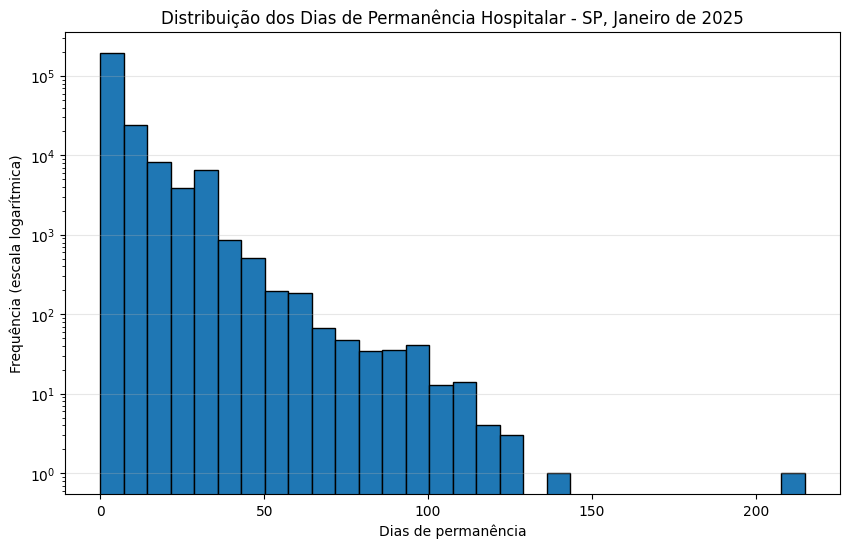

In [ ]:
import matplotlib.pyplot as plt

# Item 4 - Histograma dos dias de permanência hospitalar

plt.figure(figsize=(10, 6))

plt.hist(
    df["DIAS_PERM"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.yscale("log")

plt.title("Distribuição dos Dias de Permanência Hospitalar - SP, Janeiro de 2025")
plt.xlabel("Dias de permanência")
plt.ylabel("Frequência (escala logarítmica)")

plt.grid(axis="y", alpha=0.3)
plt.show()

**Análise do Histograma sobre a distribuição dos dados**


A distribuição dos dias de permanência hospitalar apresenta forte assimetria à direita. A maior concentração de registros encontra-se nos menores tempos de permanência, indicando que grande parte das internações possui duração relativamente curta. Conforme o número de dias de internação aumenta, observa-se uma redução acentuada na frequência dos registros.
Existem regiões com poucos dados, principalmente entre os maiores tempos de permanência. Após aproximadamente 100 dias, os registros tornam-se bastante escassos, embora ainda sejam observados alguns casos isolados com duração superior a esse período.
Uma característica que chama atenção é a formação de uma cauda longa à direita, causada pela existência de um pequeno número de internações com duração muito superior à maioria. O histograma mostra inclusive registros próximos de 140 dias e superiores a 200 dias. Esses valores podem representar possíveis valores atípicos (outliers) e serão investigados posteriormente para verificar se correspondem a internações prolongadas plausíveis ou a alguma particularidade dos registros.
Para melhorar a visualização dessa distribuição, foi utilizada escala logarítmica no eixo da frequência, pois a grande concentração de internações de curta duração dificultava a visualização das classes com menor frequência. Essa alteração modifica apenas a forma de apresentação do gráfico, sem alterar os dados analisados.


**Histograma 2 – Distribuição dos Dias de Permanência Hospitalar (60 intervalos)**

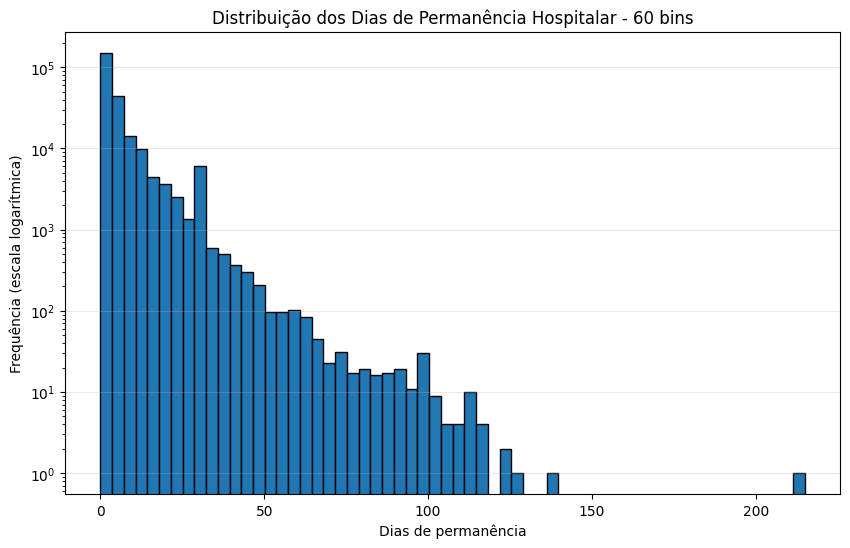

In [ ]:
# Item 6 - Segundo histograma com maior número de intervalos

plt.figure(figsize=(10, 6))

plt.hist(
    df["DIAS_PERM"].dropna(),
    bins=60,
    edgecolor="black"
)

plt.yscale("log")

plt.title("Distribuição dos Dias de Permanência Hospitalar - 60 bins")
plt.xlabel("Dias de permanência")
plt.ylabel("Frequência (escala logarítmica)")

plt.grid(axis="y", alpha=0.3)
plt.show()


**Comparação entre os histogramas**


Quanto à percepção geral da distribuição, em ambos os histogramas observa-se uma distribuição fortemente assimétrica à direita, com grande concentração de internações de curta duração e redução progressiva da frequência conforme aumentam os dias de permanência. Também permanece evidente a existência de uma cauda longa, com poucos registros de internações muito prolongadas.
Entretanto, o Histograma 2, com 60 intervalos, apresenta maior nível de detalhamento. Com intervalos menores, algumas variações de frequência que estavam agrupadas no histograma de 30 intervalos tornam-se mais visíveis. É possível perceber melhor as oscilações ao longo da distribuição e a existência de pequenos agrupamentos em determinadas faixas, além dos registros isolados de longa permanência. O valor superior a 200 dias, por exemplo, aparece de maneira bastante evidente como um registro extremamente distante da região de maior concentração.
A quantidade de bins influencia diretamente a interpretação de um histograma. Poucos intervalos agrupam uma quantidade maior de valores em cada classe, produzindo uma representação mais simples, porém podendo esconder características da distribuição. Por outro lado, um número maior de intervalos fornece mais detalhes e permite visualizar variações locais, mas, quando utilizado em excesso, pode tornar o gráfico fragmentado e dificultar a identificação do comportamento geral dos dados.
Neste caso, os 30 intervalos proporcionam uma visão mais resumida da forma geral da distribuição, enquanto os 60 intervalos permitem explorar melhor seus detalhes. Apesar dessas diferenças de visualização, ambos sustentam a mesma conclusão principal: os dias de permanência apresentam forte concentração em valores baixos e uma longa cauda à direita, com poucos casos de internações muito prolongadas.


**Boxplot – Distribuição dos Dias de Permanência Hospitalar**

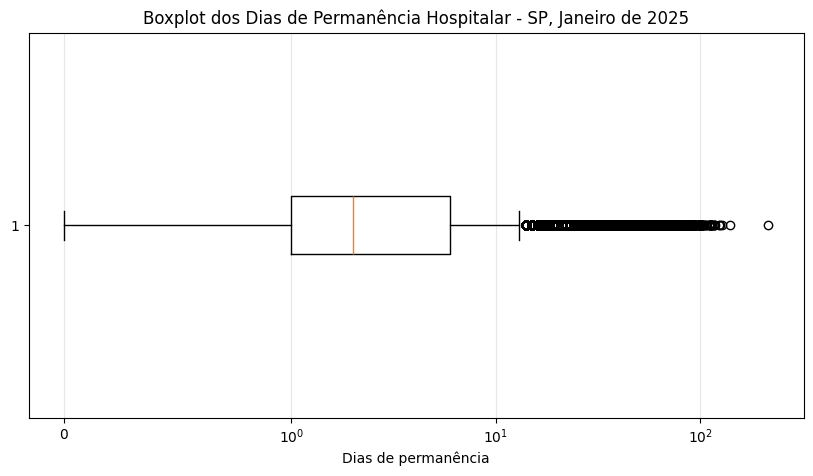

In [ ]:
# Boxplot dos dias de permanência hospitalar

plt.figure(figsize=(10, 5))

plt.boxplot(
    df["DIAS_PERM"].dropna(),
    vert=False,
    showfliers=True
)

# Ajuste da escala para melhorar a visualização da distribuição
plt.xscale("symlog", linthresh=1)

plt.title("Boxplot dos Dias de Permanência Hospitalar - SP, Janeiro de 2025")
plt.xlabel("Dias de permanência")
plt.grid(axis="x", alpha=0.3)

plt.show()


**Verificação de um possível outlier diretamente na base**

O valor de 215 dias de permanência hospitalar é claramente atípico em relação à maior parte dos registros analisados, porém sua ocorrência isolada não permite classificá-lo automaticamente como um erro. Internações de longa duração podem ocorrer e, portanto, esse valor pode representar uma observação rara, mas plausível.
Por outro lado, apenas a variável DIAS_PERM não fornece informações suficientes para confirmar se os 215 dias correspondem efetivamente a uma internação prolongada válida ou se existe alguma inconsistência no registro. Para uma avaliação mais segura, seria necessário analisar outras informações associadas à internação, como diagnóstico, procedimentos realizados e demais características disponíveis no registro.



In [ ]:
# Verificação de um possível outlier diretamente na base

maior_valor = df["DIAS_PERM"].max()

registro_outlier = df[df["DIAS_PERM"] == maior_valor]

print("Maior valor encontrado em DIAS_PERM:", maior_valor, "dias")
print("Quantidade de registros com esse valor:", len(registro_outlier))

display(registro_outlier)

Maior valor encontrado em DIAS_PERM: 215 dias
Quantidade de registros com esse valor: 1


,UF_ZI,ANO_CMPT,MES_CMPT,ESPEC,CGC_HOSP,N_AIH,IDENT,CEP,MUNIC_RES,NASC,...,DIAGSEC9,TPDISEC1,TPDISEC2,TPDISEC3,TPDISEC4,TPDISEC5,TPDISEC6,TPDISEC7,TPDISEC8,TPDISEC9
218342,355030,2025,01,07,46392148001000,3524121722132,1,02675030,355030,20240429,...,,1,0,0,0,0,0,0,0,0


**Comparação entre o histograma e o boxplot**

Tanto o histograma quanto o boxplot mostram que a distribuição dos dias de permanência hospitalar apresenta forte assimetria à direita, com predominância de internações de curta duração e presença de poucos registros com tempos de permanência muito elevados. Dessa forma, os dois gráficos evidenciam que os dados não estão distribuídos de maneira simétrica e apresentam valores extremos na parte superior da distribuição.
No histograma, fica mais clara a forma da distribuição e a frequência dos registros em diferentes faixas de dias. É possível observar onde ocorre a maior concentração de internações, como essa frequência diminui à medida que o tempo de permanência aumenta e a formação de uma cauda longa à direita. O uso da escala logarítmica também permitiu visualizar melhor as faixas com menor frequência.
Já o boxplot facilita a visualização da posição central e da dispersão dos dados, representadas pela mediana, pelos quartis e pelos bigodes. Além disso, destaca de maneira mais direta os possíveis valores atípicos, que aparecem como pontos além dos limites dos bigodes. Foi por meio dessa análise que se tornou evidente a existência de diversos possíveis outliers, incluindo o caso extremo de 215 dias de permanência.
Assim, os gráficos são complementares: o histograma oferece uma visão mais detalhada do formato e das frequências da distribuição, enquanto o boxplot sintetiza sua posição, dispersão e evidencia com maior clareza a presença de possíveis valores atípicos.

**Comparação entre média e mediana**


A média dos dias de permanência hospitalar foi de 5,19 dias, enquanto a mediana foi de 2 dias. Portanto, a média apresenta valor consideravelmente superior à mediana.
Essa diferença ocorre porque a distribuição possui valores elevados de permanência, incluindo internações muito prolongadas, que exercem maior influência sobre a média. A mediana, por sua vez, é menos sensível a esses valores extremos e indica que 50% dos registros apresentam permanência de até 2 dias e 50% apresentam permanência de 2 dias ou mais.
A diferença entre as duas medidas reforça o comportamento observado nos histogramas e no boxplot: a distribuição é assimétrica à direita, com grande concentração de internações de curta duração e uma quantidade menor de internações com tempos elevados de permanência.
Nesse conjunto de dados, portanto, a mediana descreve melhor o valor central típico da distribuição do que a média, já que esta é deslocada para cima pelos valores elevados presentes na cauda direita.

**Interpretação geral da variável analisada**


A análise dos dias de permanência hospitalar mostrou uma distribuição fortemente assimétrica à direita, com grande concentração de internações de curta duração e redução da frequência conforme aumenta o período de permanência. Os histogramas evidenciaram essa concentração e a formação de uma longa cauda em direção aos valores mais elevados, enquanto o boxplot destacou a presença de diversos possíveis valores atípicos. As estatísticas descritivas reforçam esse comportamento, com média de 5,19 dias e mediana de 2 dias, demonstrando a influência das internações prolongadas sobre a média. Metade dos registros apresentou permanência de até 2 dias, enquanto os valores centrais se concentraram entre 1 dia (Q1) e 6 dias (Q3). O maior valor identificado foi de 215 dias, presente em apenas um registro. Embora estatisticamente atípicos, os valores elevados não podem ser considerados erros apenas com as informações disponíveis, podendo representar internações prolongadas reais.